<a href="https://colab.research.google.com/github/saue10/Day15_Hotel_Booking_EDA/blob/main/Day15_Hotel_Booking_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv("/content/Day15_Executive_Hotel_Booking_EDA_Dataset.csv")

In [4]:
print(df.head())
print(df.columns)
print(df.isnull().sum())
print(df.info())
print(df.shape)
print(df.dtypes)

  Booking_ID  Hotel_Type Hotel_Location Booking_Date Arrival_Date  \
0  HTL024548  City Hotel         London   2024-07-29   2025-07-04   
1  HTL019878  City Hotel         London   2024-05-28   2025-02-08   
2  HTL017377  City Hotel         Lisbon   2024-05-10   2024-06-20   
3  HTL003352  City Hotel         Lisbon   2024-03-15   2024-04-07   
4  HTL012521  City Hotel         London   2024-08-21   2025-05-30   

   Lead_Time_Days  Weekend_Nights  Weekday_Nights  Adults  Children  ...  \
0             340               2               2       2       0.0  ...   
1             256               1               2       2       2.0  ...   
2              41               1               1       4       0.0  ...   
3              23               0               2       2       0.0  ...   
4             282               0               3       4       0.0  ...   

   Meal_Type Total_Nights     ADR Required_Car_Parking_Spaces  \
0         HB            4  178.66                           0  

In [6]:
print(df.duplicated().sum())

180


In [8]:
df=df.drop_duplicates()
print(df.shape)
print(df.duplicated().sum())

(25000, 35)
0


In [9]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date',
       'Arrival_Date', 'Country', 'Market_Segment', 'Distribution_Channel',
       'Room_Type_Reserved', 'Room_Type_Assigned', 'Deposit_Type',
       'Customer_Type', 'Meal_Type', 'Reservation_Status',
       'Reservation_Status_Date'],
      dtype='object')


In [10]:
print(df["Hotel_Type"].value_counts())

Hotel_Type
City Hotel      15491
Resort Hotel     9389
CITY HOTEL         44
city hotel         43
City hotel         33
Name: count, dtype: int64


In [11]:
df["Hotel_Type"] = df["Hotel_Type"].str.strip().str.title()
print(df["Hotel_Type"].value_counts())

Hotel_Type
City Hotel      15611
Resort Hotel     9389
Name: count, dtype: int64


In [12]:
print(df["Market_Segment"].value_counts())


Market_Segment
Online TA        10702
Offline TA/TO     5440
Direct            3808
Corporate         2990
Groups            1910
ONLINE TA           52
online ta           50
Online TA           48
Name: count, dtype: int64


In [13]:
df["Market_Segment"] = df["Market_Segment"].str.strip().str.title()
print(df["Market_Segment"].value_counts())

Market_Segment
Online Ta        10852
Offline Ta/To     5440
Direct            3808
Corporate         2990
Groups            1910
Name: count, dtype: int64


In [14]:
df["Market_Segment"] = df["Market_Segment"].replace({
    "Online Ta": "Online TA",
    "Offline Ta/To": "Offline TA/TO"
})
print(df["Market_Segment"].value_counts())

Market_Segment
Online TA        10852
Offline TA/TO     5440
Direct            3808
Corporate         2990
Groups            1910
Name: count, dtype: int64


In [15]:
print(df["Deposit_Type"].value_counts())

Deposit_Type
Non Refund    12401
No Deposit    12144
Refundable      455
Name: count, dtype: int64


In [16]:
print(df["Meal_Type"].value_counts())

Meal_Type
BB           5002
Undefined    4943
FB           4910
SC           4906
HB           4893
BB             38
bb             32
 B&B           30
Unknown         7
Name: count, dtype: int64


In [19]:
df["Meal_Type"] = df["Meal_Type"].replace({
    "BB": "BB",
    "bb": "BB",
    " B&B": "BB"
})


In [21]:
df["Meal_Type"] = df["Meal_Type"].str.strip()
print(df["Meal_Type"].value_counts())

Meal_Type
BB           5072
Undefined    4943
FB           4910
SC           4906
HB           4893
B&B            30
Unknown         7
Name: count, dtype: int64


In [22]:
df['Meal_Type']=df['Meal_Type'].replace({'B&B': "BB"})

In [23]:
print(df["Meal_Type"].value_counts())

Meal_Type
BB           5102
Undefined    4943
FB           4910
SC           4906
HB           4893
Unknown         7
Name: count, dtype: int64


In [24]:
print(df["Meal_Type"].isnull().sum())

239


In [26]:
df["Meal_Type"] = df["Meal_Type"].fillna("Unknown")
print(df["Meal_Type"].value_counts())

Meal_Type
BB           5102
Undefined    4943
FB           4910
SC           4906
HB           4893
Unknown       246
Name: count, dtype: int64


In [27]:
print(df["Customer_Type"].value_counts())

Customer_Type
Contract           6403
Transient-Party    6287
Group              6283
Transient          6027
Name: count, dtype: int64


In [28]:
print(df["Distribution_Channel"].value_counts())

Distribution_Channel
TA/TO        16887
Direct        4471
Corporate     3642
Name: count, dtype: int64


In [29]:
print(df["Room_Type_Reserved"].value_counts())

Room_Type_Reserved
D    3207
C    3182
H    3147
A    3139
G    3133
E    3111
F    3104
B    2977
Name: count, dtype: int64


In [30]:
print(df["Room_Type_Assigned"].value_counts())


Room_Type_Assigned
C    3199
D    3195
E    3150
H    3146
G    3138
A    3126
F    3040
B    3006
Name: count, dtype: int64


In [32]:
df["Booking_Date"] = pd.to_datetime(df["Booking_Date"])
df["Arrival_Date"] = pd.to_datetime(df["Arrival_Date"])
df["Reservation_Status_Date"] = pd.to_datetime(df["Reservation_Status_Date"])
print(df[["Booking_Date","Arrival_Date","Reservation_Status_Date"]].dtypes)

Booking_Date               datetime64[ns]
Arrival_Date               datetime64[ns]
Reservation_Status_Date    datetime64[ns]
dtype: object


In [33]:
print(df.isnull().sum())

Booking_ID                         0
Hotel_Type                         0
Hotel_Location                   105
Booking_Date                       0
Arrival_Date                       0
Lead_Time_Days                     0
Weekend_Nights                     0
Weekday_Nights                     0
Adults                             0
Children                         120
Babies                             0
Country                          462
Market_Segment                     0
Distribution_Channel               0
Is_Repeated_Guest                  0
Previous_Cancellations             0
Previous_Bookings                  0
Room_Type_Reserved                 0
Room_Type_Assigned                 0
Booking_Changes                    0
Deposit_Type                       0
Agent_ID                         300
Company_ID                     20585
Days_In_Waiting_List               0
Customer_Type                      0
Meal_Type                          0
Total_Nights                       0
A

In [36]:
df["Company_ID"]=df["Company_ID"].fillna(df["Company_ID"].mean())
print(df["Company_ID"].isnull().sum())

0


In [38]:
df["Hotel_Location"] = df["Hotel_Location"].fillna("Unknown")
df["Country"] = df["Country"].fillna("Unknown")
print(df[["Hotel_Location", "Country"]].isnull().sum())

Hotel_Location    0
Country           0
dtype: int64


In [39]:
print(df["Children"].median())

0.0


In [40]:
df["Children"] = df["Children"].fillna(df["Children"].median())
print(df["Children"].isnull().sum())

0


In [42]:
print(df["ADR"].median())
print(df["ADR"].mean())

134.405
140.6079903691814


In [43]:
df["ADR"] = df["ADR"].fillna(df["ADR"].median())
print(df["ADR"].isnull().sum())

0


In [45]:
print(df["Satisfaction_Score"].median())
print(df["Satisfaction_Score"].mean())

3.86
3.854369162640902


In [46]:
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(df["Satisfaction_Score"].median())
print(df["Satisfaction_Score"].isnull().sum())

0


In [48]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Agent_ID    300
dtype: int64


In [49]:
print(df.describe())

                     Booking_Date                Arrival_Date  Lead_Time_Days  \
count                       25000                       25000    25000.000000   
mean   2025-01-01 02:16:03.072000  2025-07-02 05:55:37.344000      182.217400   
min           2024-01-01 00:00:00         2024-01-02 00:00:00        0.000000   
25%           2024-07-01 00:00:00         2024-12-30 00:00:00       91.000000   
50%           2024-12-30 12:00:00         2025-07-02 00:00:00      182.000000   
75%           2025-07-05 00:00:00         2026-01-03 00:00:00      273.000000   
max           2025-12-31 00:00:00         2026-12-29 00:00:00      920.000000   
std                           NaN                         NaN      105.632493   

       Weekend_Nights  Weekday_Nights        Adults     Children       Babies  \
count    25000.000000     25000.00000  25000.000000  25000.00000  25000.00000   
mean         1.240880         2.45000      2.198480      0.37068      0.04312   
min          0.000000      

In [51]:
Q1 = df["ADR"].quantile(0.25)
Q3 = df["ADR"].quantile(0.75)
IQR = Q3 - Q1
print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 105.6975
Q3 = 168.95499999999998
IQR = 63.25749999999998


In [52]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = 10.811250000000044
Upper Bound = 263.84124999999995


In [53]:
outliers = df[(df["ADR"] < lower_bound) | (df["ADR"] > upper_bound)]

print("Number of ADR outliers:", len(outliers))

Number of ADR outliers: 360


In [54]:
print(outliers["ADR"].describe())

count    360.000000
mean     282.390611
std       31.406644
min      263.920000
25%      270.057500
50%      277.325000
75%      287.657500
max      710.500000
Name: ADR, dtype: float64


In [55]:
print(df.nlargest(10, "ADR")[[
    "Hotel_Type",
    "Hotel_Location",
    "Room_Type_Reserved",
    "Room_Type_Assigned",
    "ADR",
    "Total_Nights",
    "Estimated_Revenue"
]])

         Hotel_Type Hotel_Location Room_Type_Reserved Room_Type_Assigned  \
12103    City Hotel      Barcelona                  G                  G   
8590     City Hotel          Dubai                  G                  G   
6582   Resort Hotel         Phuket                  H                  H   
9004   Resort Hotel        Algarve                  H                  H   
3204   Resort Hotel            Goa                  H                  H   
14735  Resort Hotel            Goa                  H                  B   
23928  Resort Hotel            Goa                  H                  H   
14524  Resort Hotel            Goa                  H                  H   
8742   Resort Hotel        Algarve                  H                  H   
17843  Resort Hotel       Maldives                  H                  H   

          ADR  Total_Nights  Estimated_Revenue  
12103  710.50             6             941.35  
8590   620.00             7            1395.21  
6582   325.96   

In [56]:
Q1 = df["Lead_Time_Days"].quantile(0.25)
Q3 = df["Lead_Time_Days"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 91.0
Q3 = 273.0
IQR = 182.0


In [57]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = -182.0
Upper Bound = 546.0


In [58]:
outliers_lead = df[
    (df["Lead_Time_Days"] < lower_bound) |
    (df["Lead_Time_Days"] > upper_bound)
]

print("Number of Lead Time outliers:", len(outliers_lead))

Number of Lead Time outliers: 2


In [59]:
print(df.nlargest(2, "Lead_Time_Days")[[
    "Hotel_Type",
    "Hotel_Location",
    "Lead_Time_Days",
    "Arrival_Date",
    "ADR",
    "Total_Nights",
    "Is_Canceled"
]])

         Hotel_Type Hotel_Location  Lead_Time_Days Arrival_Date     ADR  \
6729   Resort Hotel            Goa             920   2025-04-01  181.27   
16730    City Hotel      Barcelona             850   2024-10-21  162.13   

       Total_Nights  Is_Canceled  
6729              3            0  
16730             1            1  


In [60]:
Q1 = df["Days_In_Waiting_List"].quantile(0.25)
Q3 = df["Days_In_Waiting_List"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 0.0
Q3 = 1.0
IQR = 1.0


In [61]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = -1.5
Upper Bound = 2.5


In [62]:
outliers_waiting = df[
    (df["Days_In_Waiting_List"] < lower_bound) |
    (df["Days_In_Waiting_List"] > upper_bound)
]

print("Number of Days In Waiting List outliers:", len(outliers_waiting))

Number of Days In Waiting List outliers: 4082


In [63]:
print(outliers_waiting["Days_In_Waiting_List"].describe())

count    4082.000000
mean        8.392945
std         8.051167
min         3.000000
25%         3.000000
50%         5.000000
75%        10.000000
max       180.000000
Name: Days_In_Waiting_List, dtype: float64


In [64]:
Q1 = df["Estimated_Revenue"].quantile(0.25)
Q3 = df["Estimated_Revenue"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 230.62
Q3 = 737.57
IQR = 506.95000000000005


In [65]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = -529.8050000000001
Upper Bound = 1497.9950000000001


In [66]:
outliers_revenue = df[
    (df["Estimated_Revenue"] < lower_bound) |
    (df["Estimated_Revenue"] > upper_bound)
]

print("Number of Estimated Revenue outliers:", len(outliers_revenue))

Number of Estimated Revenue outliers: 652


In [67]:
print(df.nlargest(10, "Estimated_Revenue")[[
    "Hotel_Type",
    "Hotel_Location",
    "ADR",
    "Total_Nights",
    "Estimated_Revenue",
    "Reservation_Status"
]])

         Hotel_Type Hotel_Location     ADR  Total_Nights  Estimated_Revenue  \
10648  Resort Hotel           Bali  250.46            13            3256.02   
16589  Resort Hotel           Bali  295.90            11            3254.89   
8499   Resort Hotel           Bali  281.90            11            3100.95   
4450   Resort Hotel        Algarve  261.46            11            2876.03   
15610  Resort Hotel       Maldives  284.36            10            2843.63   
8863   Resort Hotel         Phuket  277.85            10            2778.54   
23378    City Hotel            Goa  275.21            10            2752.06   
15639  Resort Hotel            Goa  224.55            12            2694.62   
12862  Resort Hotel        Algarve  269.13            10            2691.33   
7510   Resort Hotel         Phuket  268.68            10            2686.78   

      Reservation_Status  
10648           Canceled  
16589           Canceled  
8499           Check-Out  
4450            Cancel

In [68]:
print(df.nlargest(10, "Satisfaction_Score")[[
    "Hotel_Type",
    "Hotel_Location",
    "Satisfaction_Score",
    "ADR",
    "Reservation_Status"
]])

         Hotel_Type Hotel_Location  Satisfaction_Score     ADR  \
17445    City Hotel      Amsterdam                 5.9  103.68   
304      City Hotel         Lisbon                 5.0   82.08   
423      City Hotel      Barcelona                 5.0  133.19   
990      City Hotel      Amsterdam                 5.0  126.44   
1664     City Hotel         Lisbon                 5.0  193.91   
2252   Resort Hotel       Maldives                 5.0  148.62   
2555   Resort Hotel            Goa                 5.0  122.85   
2579     City Hotel      Barcelona                 5.0   58.80   
2705     City Hotel          Dubai                 5.0  136.28   
3081     City Hotel      Barcelona                 5.0  112.03   

      Reservation_Status  
17445            No-Show  
304             Canceled  
423             Canceled  
990             Canceled  
1664            Canceled  
2252            Canceled  
2555            Canceled  
2579            Canceled  
2705            Canceled  
308

In [69]:
print("Scores above 5:", (df["Satisfaction_Score"] > 5).sum())

Scores above 5: 1


In [70]:
import numpy as np


In [71]:
df.loc[df["Satisfaction_Score"] > 5, "Satisfaction_Score"] = np.nan

In [72]:
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(
    df["Satisfaction_Score"].median()
)

In [73]:
print(df["Satisfaction_Score"].max())
print(df["Satisfaction_Score"].isnull().sum())

5.0
0


In [74]:
print(df.describe())

                     Booking_Date                Arrival_Date  Lead_Time_Days  \
count                       25000                       25000    25000.000000   
mean   2025-01-01 02:16:03.072000  2025-07-02 05:55:37.344000      182.217400   
min           2024-01-01 00:00:00         2024-01-02 00:00:00        0.000000   
25%           2024-07-01 00:00:00         2024-12-30 00:00:00       91.000000   
50%           2024-12-30 12:00:00         2025-07-02 00:00:00      182.000000   
75%           2025-07-05 00:00:00         2026-01-03 00:00:00      273.000000   
max           2025-12-31 00:00:00         2026-12-29 00:00:00      920.000000   
std                           NaN                         NaN      105.632493   

       Weekend_Nights  Weekday_Nights        Adults     Children       Babies  \
count    25000.000000     25000.00000  25000.000000  25000.00000  25000.00000   
mean         1.240880         2.45000      2.198480      0.37068      0.04312   
min          0.000000      

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

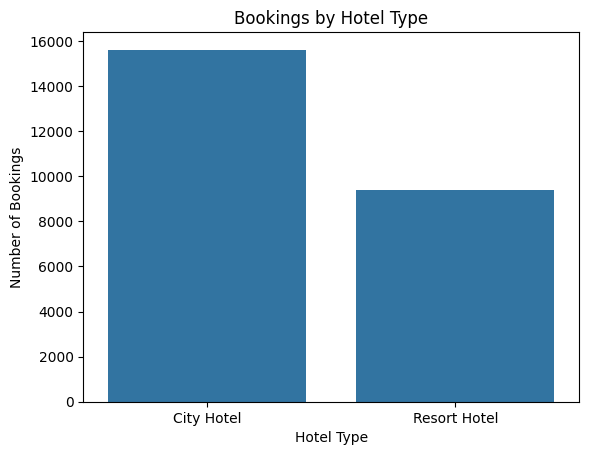

In [76]:
sns.countplot(data=df, x="Hotel_Type")

plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

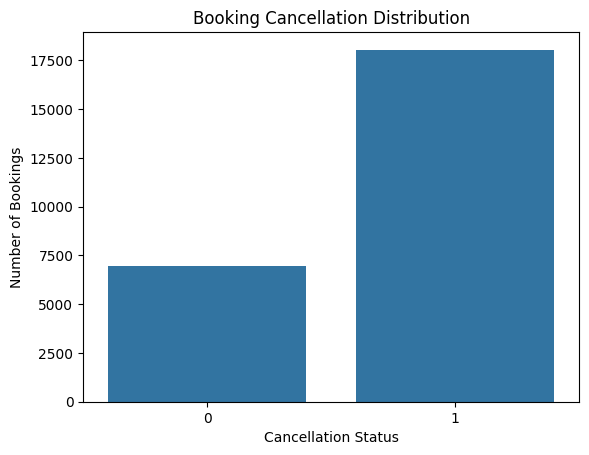

In [77]:
sns.countplot(data=df, x="Is_Canceled")

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.show()

In [78]:
cancellation_rate = df["Is_Canceled"].value_counts(normalize=True) * 100

print(cancellation_rate)

Is_Canceled
1    72.176
0    27.824
Name: proportion, dtype: float64


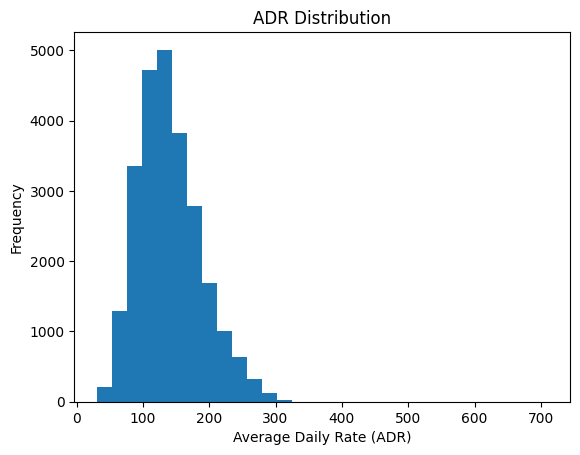

In [79]:
plt.hist(df["ADR"], bins=30)

plt.title("ADR Distribution")
plt.xlabel("Average Daily Rate (ADR)")
plt.ylabel("Frequency")
plt.show()

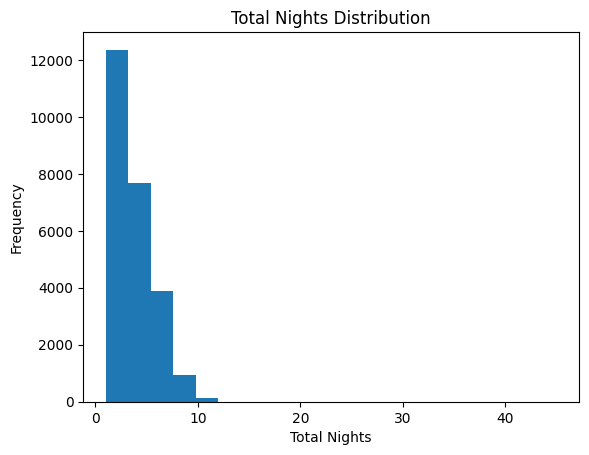

In [80]:
plt.hist(df["Total_Nights"], bins=20)

plt.title("Total Nights Distribution")
plt.xlabel("Total Nights")
plt.ylabel("Frequency")
plt.show()

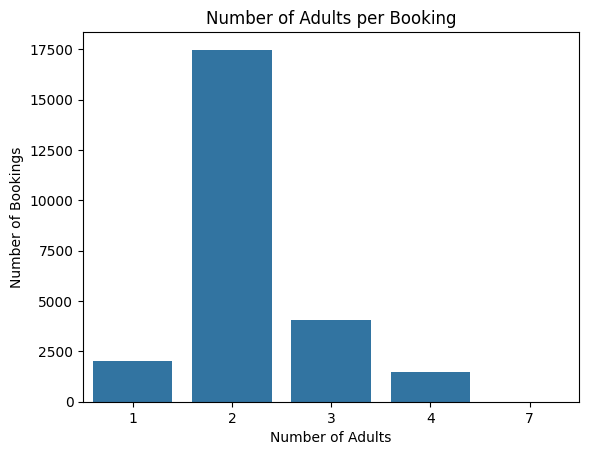

In [81]:
sns.countplot(data=df, x="Adults")

plt.title("Number of Adults per Booking")
plt.xlabel("Number of Adults")
plt.ylabel("Number of Bookings")
plt.show()

In [82]:
cancellation_by_hotel = df.groupby("Hotel_Type")["Is_Canceled"].mean() * 100

print(cancellation_by_hotel)

Hotel_Type
City Hotel      73.300878
Resort Hotel    70.305677
Name: Is_Canceled, dtype: float64


In [83]:
df["Lead_Time_Group"] = pd.cut(
    df["Lead_Time_Days"],
    bins=[-1, 90, 180, 365, float("inf")],
    labels=["0-90", "91-180", "181-365", "366+"]
)

In [84]:
cancellation_by_lead = df.groupby(
    "Lead_Time_Group", observed=True
)["Is_Canceled"].mean() * 100

print(cancellation_by_lead)

Lead_Time_Group
0-90       49.927734
91-180     66.893534
181-365    85.761905
366+       50.000000
Name: Is_Canceled, dtype: float64


In [85]:
print(df["Lead_Time_Group"].value_counts().sort_index())

Lead_Time_Group
0-90        6227
91-180      6171
181-365    12600
366+           2
Name: count, dtype: int64


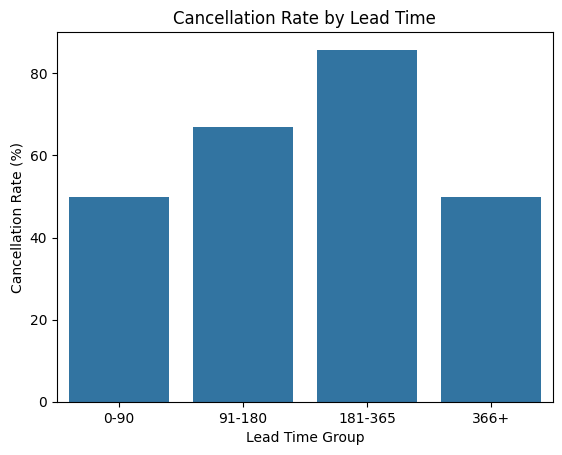

In [86]:
sns.barplot(
    x=cancellation_by_lead.index,
    y=cancellation_by_lead.values
)

plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [87]:
cancellation_by_market = df.groupby(
    "Market_Segment"
)["Is_Canceled"].mean() * 100

print(cancellation_by_market)

Market_Segment
Corporate        67.491639
Direct           71.218487
Groups           69.790576
Offline TA/TO    70.422794
Online TA        75.101364
Name: Is_Canceled, dtype: float64


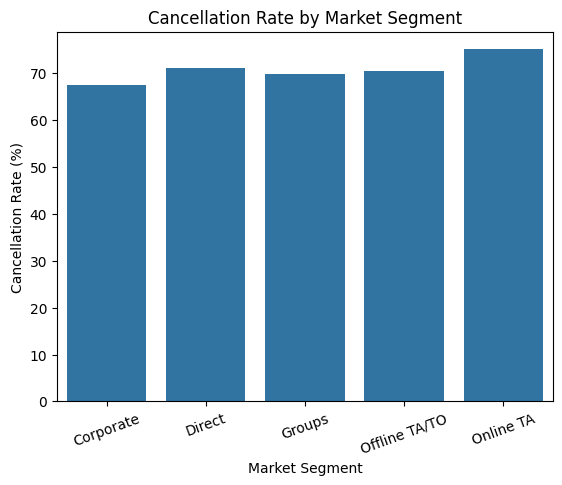

In [88]:
sns.barplot(
    x=cancellation_by_market.index,
    y=cancellation_by_market.values
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [89]:
cancellation_by_deposit = df.groupby(
    "Deposit_Type"
)["Is_Canceled"].mean() * 100

print(cancellation_by_deposit)

Deposit_Type
No Deposit    51.589262
Non Refund    92.976373
Refundable    54.725275
Name: Is_Canceled, dtype: float64


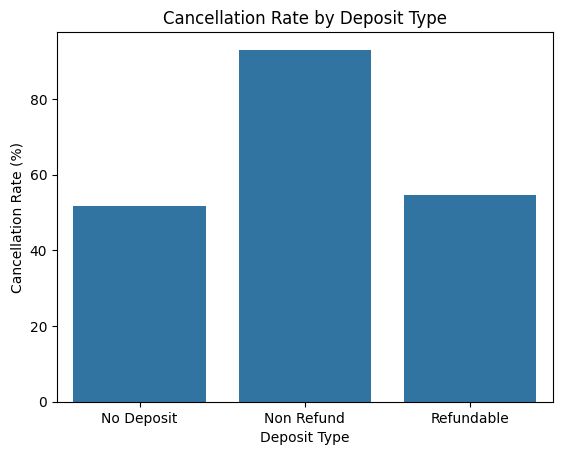

In [90]:
sns.barplot(
    x=cancellation_by_deposit.index,
    y=cancellation_by_deposit.values
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [91]:
revenue_by_hotel = df.groupby(
    "Hotel_Type"
)["Estimated_Revenue"].mean()

print(revenue_by_hotel)

Hotel_Type
City Hotel      385.518192
Resort Hotel    784.521775
Name: Estimated_Revenue, dtype: float64


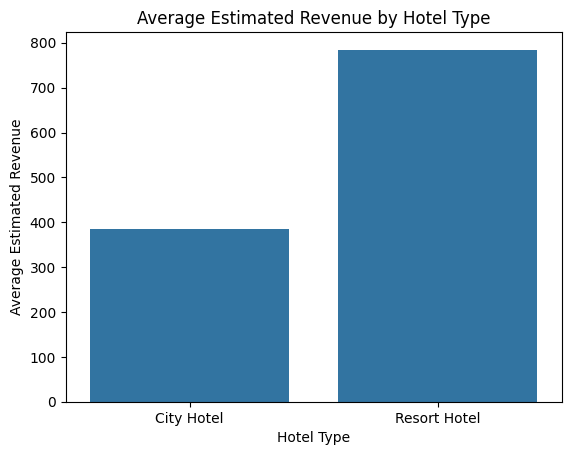

In [92]:
sns.barplot(
    x=revenue_by_hotel.index,
    y=revenue_by_hotel.values
)

plt.title("Average Estimated Revenue by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Estimated Revenue")
plt.show()

In [93]:
adr_by_hotel = df.groupby(
    "Hotel_Type"
)["ADR"].mean()

print(adr_by_hotel)

Hotel_Type
City Hotel      120.759541
Resort Hotel    173.556962
Name: ADR, dtype: float64


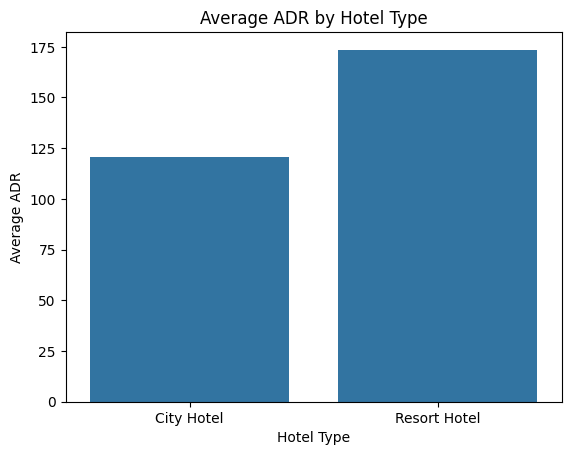

In [94]:
sns.barplot(
    x=adr_by_hotel.index,
    y=adr_by_hotel.values
)

plt.title("Average ADR by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")
plt.show()

In [95]:
revenue_by_location = df.groupby(
    "Hotel_Location"
)["Estimated_Revenue"].mean().sort_values(ascending=False)

print(revenue_by_location)

Hotel_Location
Goa          801.229509
Bali         794.020037
Maldives     778.032396
Phuket       774.271710
Algarve      773.862787
Unknown      583.775413
London       388.752833
Dubai        386.566414
Barcelona    383.888412
Lisbon       380.659031
Amsterdam    379.442139
Name: Estimated_Revenue, dtype: float64


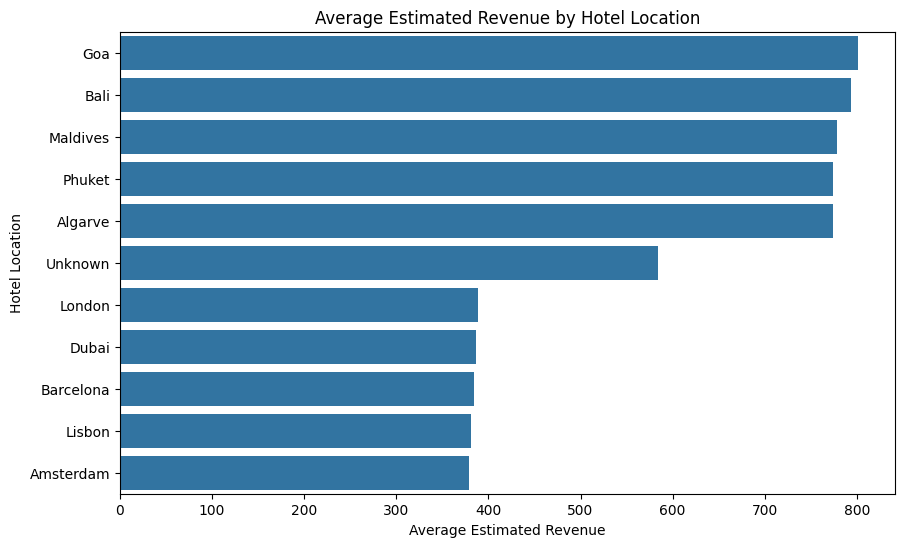

In [96]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=revenue_by_location.values,
    y=revenue_by_location.index
)

plt.title("Average Estimated Revenue by Hotel Location")
plt.xlabel("Average Estimated Revenue")
plt.ylabel("Hotel Location")
plt.show()

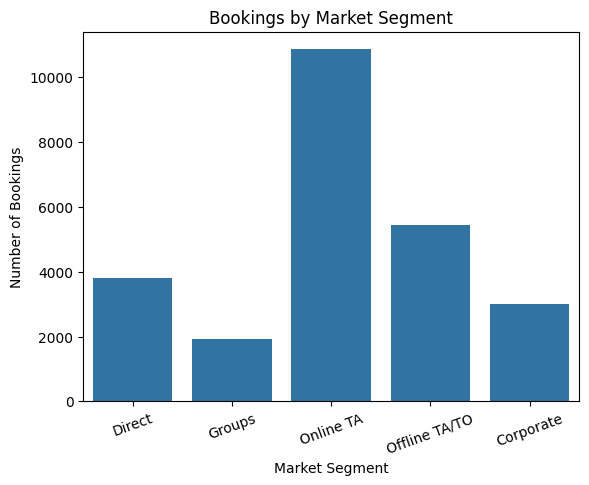

In [97]:
sns.countplot(
    data=df,
    x="Market_Segment"
)

plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)
plt.show()

In [98]:
market_counts = df["Market_Segment"].value_counts()
market_percent = df["Market_Segment"].value_counts(normalize=True) * 100

print("Booking Counts:")
print(market_counts)

print("\nBooking Percentage:")
print(market_percent)

Booking Counts:
Market_Segment
Online TA        10852
Offline TA/TO     5440
Direct            3808
Corporate         2990
Groups            1910
Name: count, dtype: int64

Booking Percentage:
Market_Segment
Online TA        43.408
Offline TA/TO    21.760
Direct           15.232
Corporate        11.960
Groups            7.640
Name: proportion, dtype: float64


In [99]:
revenue_by_market = df.groupby(
    "Market_Segment"
)["Estimated_Revenue"].mean().sort_values(ascending=False)

print(revenue_by_market)

Market_Segment
Direct           550.958506
Online TA        546.628110
Offline TA/TO    541.230465
Corporate        499.201207
Groups           480.228204
Name: Estimated_Revenue, dtype: float64


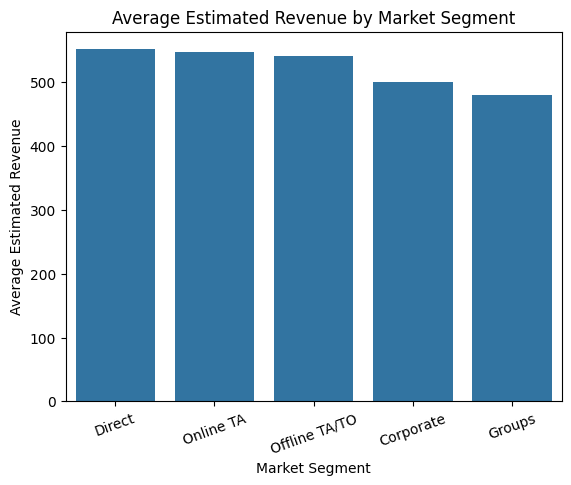

In [100]:
sns.barplot(
    x=revenue_by_market.index,
    y=revenue_by_market.values
)

plt.title("Average Estimated Revenue by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Average Estimated Revenue")
plt.xticks(rotation=20)
plt.show()

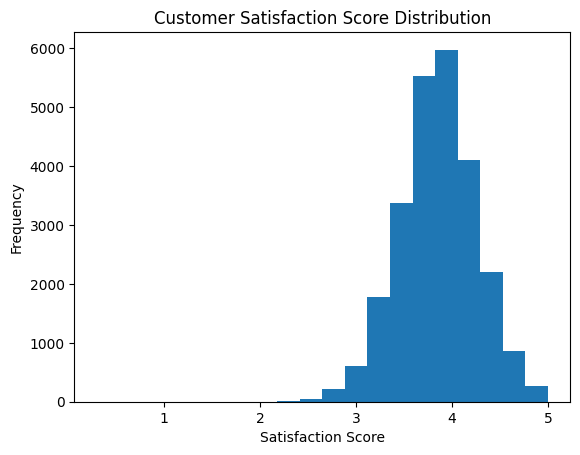

In [101]:
plt.hist(df["Satisfaction_Score"], bins=20)

plt.title("Customer Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.show()

In [102]:
satisfaction_by_hotel = df.groupby(
    "Hotel_Type"
)["Satisfaction_Score"].mean()

print(satisfaction_by_hotel)

Hotel_Type
City Hotel      3.851801
Resort Hotel    3.858518
Name: Satisfaction_Score, dtype: float64


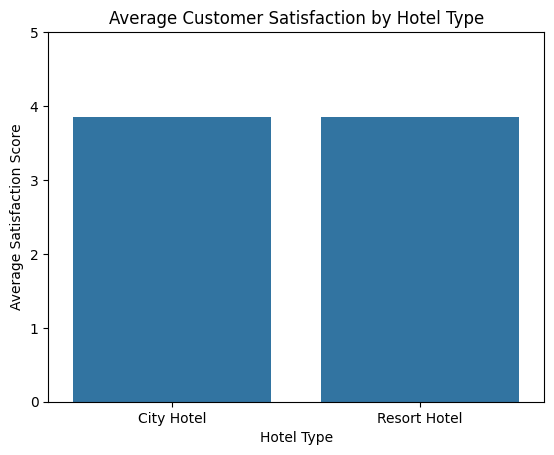

In [103]:
sns.barplot(
    x=satisfaction_by_hotel.index,
    y=satisfaction_by_hotel.values
)

plt.title("Average Customer Satisfaction by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Satisfaction Score")
plt.ylim(0, 5)
plt.show()

In [104]:
room_counts = df["Room_Type_Reserved"].value_counts()

print(room_counts)

Room_Type_Reserved
D    3207
C    3182
H    3147
A    3139
G    3133
E    3111
F    3104
B    2977
Name: count, dtype: int64


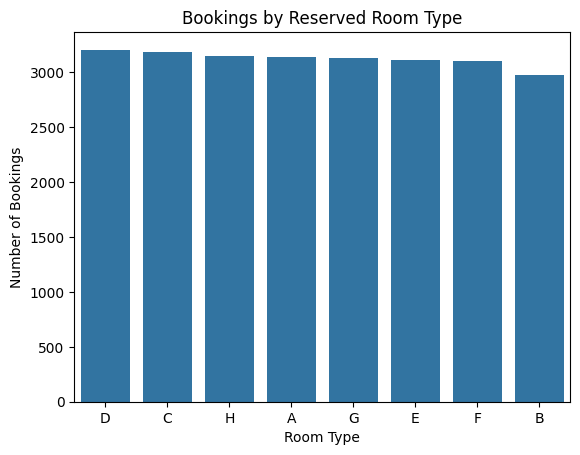

In [105]:
sns.countplot(
    data=df,
    x="Room_Type_Reserved",
    order=room_counts.index
)

plt.title("Bookings by Reserved Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")
plt.show()

In [106]:
corr_matrix = df.select_dtypes(include="number").corr()

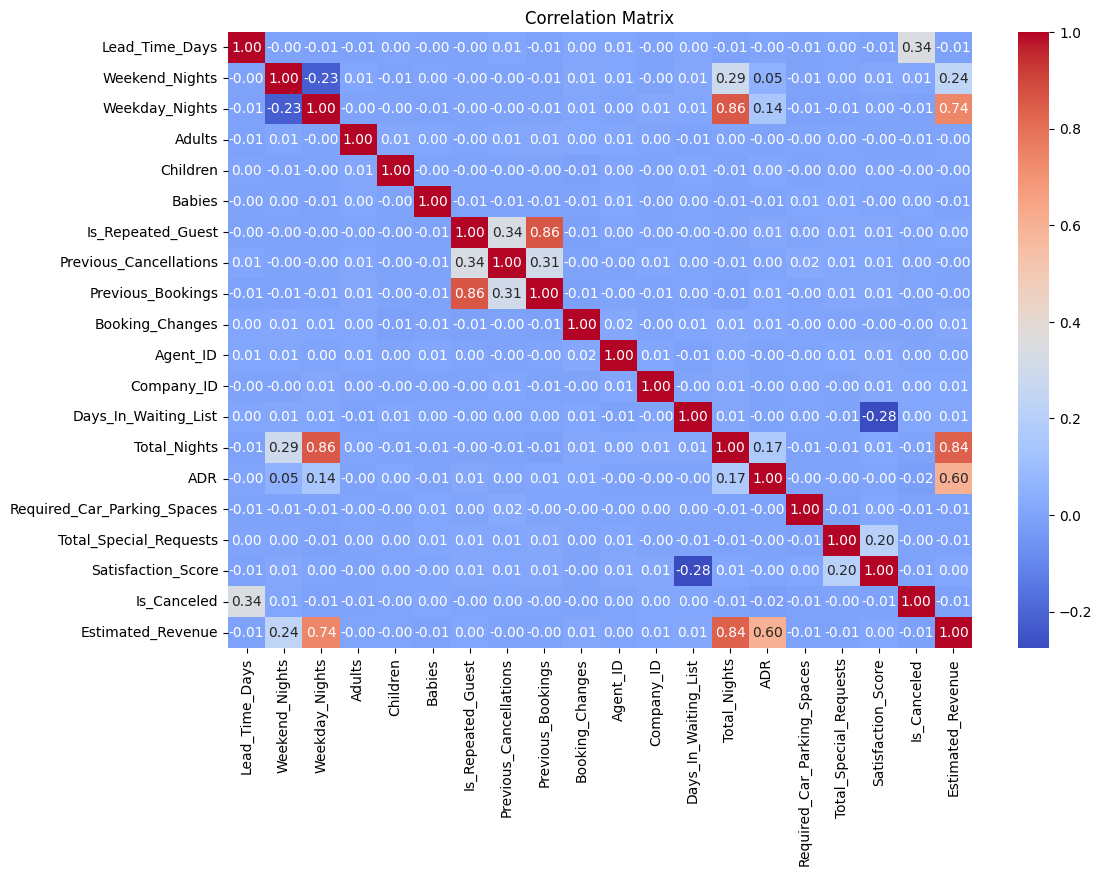

In [107]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [109]:
print(df.columns)

Index(['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date',
       'Arrival_Date', 'Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights',
       'Adults', 'Children', 'Babies', 'Country', 'Market_Segment',
       'Distribution_Channel', 'Is_Repeated_Guest', 'Previous_Cancellations',
       'Previous_Bookings', 'Room_Type_Reserved', 'Room_Type_Assigned',
       'Booking_Changes', 'Deposit_Type', 'Agent_ID', 'Company_ID',
       'Days_In_Waiting_List', 'Customer_Type', 'Meal_Type', 'Total_Nights',
       'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests',
       'Satisfaction_Score', 'Reservation_Status', 'Is_Canceled',
       'Reservation_Status_Date', 'Estimated_Revenue', 'Lead_Time_Group'],
      dtype='object')


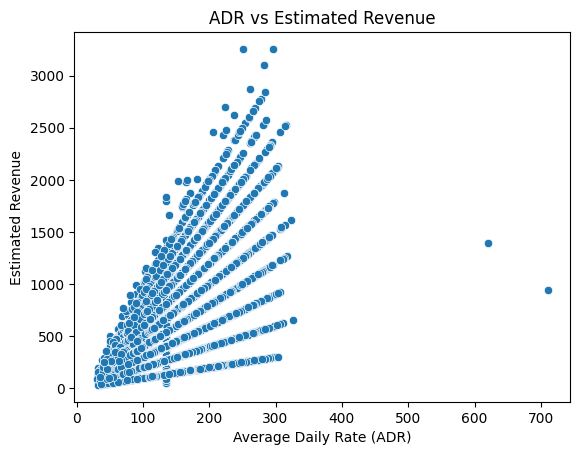

In [110]:
sns.scatterplot(
    data=df,
    x="ADR",
    y="Estimated_Revenue"
)

plt.title("ADR vs Estimated Revenue")
plt.xlabel("Average Daily Rate (ADR)")
plt.ylabel("Estimated Revenue")
plt.show()

In [111]:
print(df["ADR"].corr(df["Estimated_Revenue"]))

0.6029869920382974


In [112]:
print(df["Total_Nights"].corr(df["Estimated_Revenue"]))

0.8379653399877133


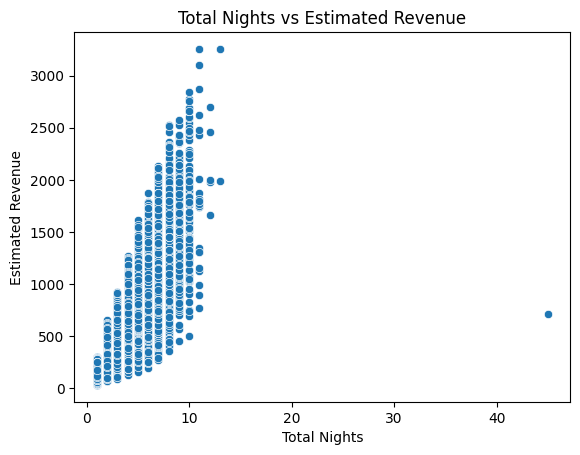

In [113]:
sns.scatterplot(
    data=df,
    x="Total_Nights",
    y="Estimated_Revenue"
)

plt.title("Total Nights vs Estimated Revenue")
plt.xlabel("Total Nights")
plt.ylabel("Estimated Revenue")
plt.show()

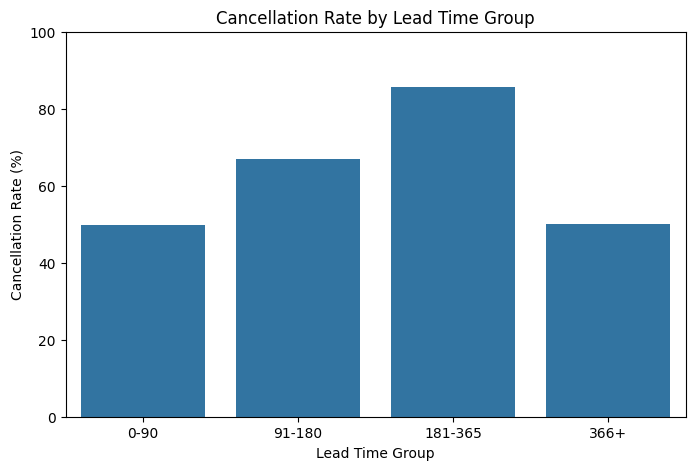

In [114]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cancellation_by_lead.index,
    y=cancellation_by_lead.values
)

plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, 100)
plt.show()

In [115]:
print("""
========================================
        KEY BUSINESS INSIGHTS
========================================

1. High Cancellation Rate
   The overall cancellation rate is 72.18%, indicating that
   cancellations are a major business concern.

2. Lead Time and Cancellation
   Cancellation rates increase from 49.93% for bookings made
   0–90 days in advance to 85.76% for bookings made
   181–365 days in advance.

3. Deposit Type and Cancellation
   Non-refundable bookings have the highest cancellation rate
   at 92.98%, compared with 51.59% for No Deposit and 54.73%
   for Refundable bookings.

4. Online TA is the Dominant Booking Channel
   Online TA accounts for 43.41% of all bookings and also has
   the highest cancellation rate at 75.10%.

5. Longer Stays Generate Higher Revenue
   Total Nights has a strong positive correlation of 0.838
   with Estimated Revenue. Resort Hotels also generate higher
   average estimated revenue (784.52) than City Hotels (385.52).
""")


        KEY BUSINESS INSIGHTS

1. High Cancellation Rate
   The overall cancellation rate is 72.18%, indicating that
   cancellations are a major business concern.

2. Lead Time and Cancellation
   Cancellation rates increase from 49.93% for bookings made
   0–90 days in advance to 85.76% for bookings made
   181–365 days in advance.

3. Deposit Type and Cancellation
   Non-refundable bookings have the highest cancellation rate
   at 92.98%, compared with 51.59% for No Deposit and 54.73%
   for Refundable bookings.

4. Online TA is the Dominant Booking Channel
   Online TA accounts for 43.41% of all bookings and also has
   the highest cancellation rate at 75.10%.

5. Longer Stays Generate Higher Revenue
   Total Nights has a strong positive correlation of 0.838
   with Estimated Revenue. Resort Hotels also generate higher
   average estimated revenue (784.52) than City Hotels (385.52).



In [116]:
print("""
========================================
      MANAGEMENT RECOMMENDATIONS
========================================

1. Strengthen Cancellation Management
   Review cancellation policies and introduce appropriate
   deposits or cancellation deadlines for high-risk bookings.

2. Target Long-Lead Bookings
   Use confirmation reminders and periodic re-confirmation
   for bookings made several months in advance.

3. Investigate Non-Refundable Bookings
   Analyze why the Non Refund category has a 92.98% cancellation
   rate and verify that the booking/deposit classification is
   being recorded correctly.

4. Improve Online TA Booking Quality
   Work with Online Travel Agency partners to reduce cancellations
   through better confirmation processes and suitable payment terms.

5. Encourage Longer Stays
   Introduce multi-night packages, extended-stay discounts,
   and bundled services to encourage customers to stay longer.

6. Optimize Resort Revenue
   Focus on premium packages and revenue optimization in resort
   properties because they generate higher ADR and average revenue.

7. Monitor Pricing and Revenue Together
   Use demand and booking patterns when adjusting ADR because
   ADR has a positive relationship with Estimated Revenue.
""")


      MANAGEMENT RECOMMENDATIONS

1. Strengthen Cancellation Management
   Review cancellation policies and introduce appropriate
   deposits or cancellation deadlines for high-risk bookings.

2. Target Long-Lead Bookings
   Use confirmation reminders and periodic re-confirmation
   for bookings made several months in advance.

3. Investigate Non-Refundable Bookings
   Analyze why the Non Refund category has a 92.98% cancellation
   rate and verify that the booking/deposit classification is
   being recorded correctly.

4. Improve Online TA Booking Quality
   Work with Online Travel Agency partners to reduce cancellations
   through better confirmation processes and suitable payment terms.

5. Encourage Longer Stays
   Introduce multi-night packages, extended-stay discounts,
   and bundled services to encourage customers to stay longer.

6. Optimize Resort Revenue
   Focus on premium packages and revenue optimization in resort
   properties because they generate higher ADR and average

In [117]:
print("""
========================================
             CONCLUSION
========================================

The EDA shows that the hotel business has strong revenue
opportunities but also faces a significant cancellation challenge.
Long lead times, Online TA bookings, and the Non Refund category
are particularly associated with higher cancellation rates.

At the same time, longer stays and higher ADR are positively
associated with booking revenue, while Resort Hotels demonstrate
higher average revenue and ADR than City Hotels.

Management should therefore focus on reducing cancellation risk,
improving the quality of high-volume booking channels, encouraging
longer stays, and optimizing pricing and revenue strategies.
""")


             CONCLUSION

The EDA shows that the hotel business has strong revenue
opportunities but also faces a significant cancellation challenge.
Long lead times, Online TA bookings, and the Non Refund category
are particularly associated with higher cancellation rates.

At the same time, longer stays and higher ADR are positively
associated with booking revenue, while Resort Hotels demonstrate
higher average revenue and ADR than City Hotels.

Management should therefore focus on reducing cancellation risk,
improving the quality of high-volume booking channels, encouraging
longer stays, and optimizing pricing and revenue strategies.



In [118]:
df.drop(columns=["Lead_Time_Group"], inplace=True)